<a href="https://colab.research.google.com/github/BalaMahender/Bala-mahender-Streaming-Service-Analysis-Project/blob/main/Car_Price_Analysis_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***1. Data Ingestion & Quality Profiling***
  

### **1.1 Load & Inspect**

1.   Read car_prices.csv into a pandas DataFrame.

In [1]:
import pandas as pd
df = pd.read_csv('/content/car_prices.csv')

In [5]:
# Display first 5 rows
print("First 5 Rows:")
display(df.head())

First 5 Rows:


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [6]:
# Display data types
print(df.dtypes)

year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object


In [7]:
# Display record count
print('Total Records:', len(df))

Total Records: 558837


### **1.2 Understanding the Data Structure**

In [9]:
# Check the shape of the dataset (rows and columns).
print('Dataset Shape:', df.shape)

Dataset Shape: (558837, 16)


In [10]:
# Display column names and data types.
print('Columns:', df.columns)

Columns: Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object')


In [11]:
# Column datatypes and record count.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB
None


### **1.3 Missing & Anomaly Detection**

In [12]:
# Quantify nulls per column; visualize with a bar chart or heatmap.
null_values = df.isnull().sum()
print(null_values)

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64


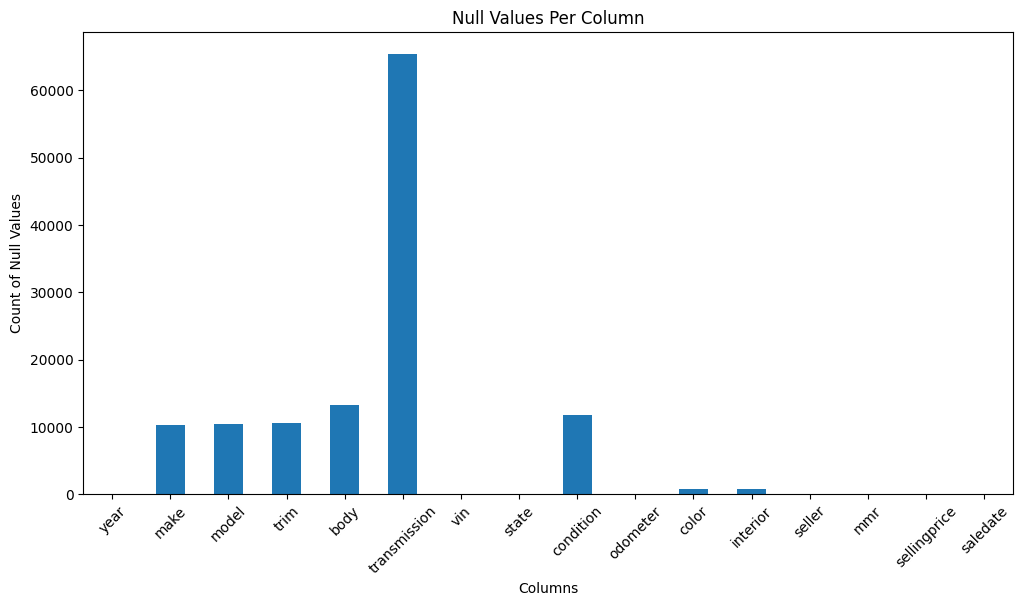

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
null_values.plot(kind='bar')
plt.title('Null Values Per Column')
plt.xlabel('Columns')
plt.ylabel('Count of Null Values')
plt.xticks(rotation=45)
plt.show()

In [3]:
# Quantify nulls per column
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

null_info = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage': null_percentages
}).sort_values(by='Null Count', ascending=False)

print("Null values per column:")
display(null_info[null_info['Null Count'] > 0])

Null values per column:


,Null Count,Null Percentage
transmission,65352,11.694287
body,13195,2.361154
condition,11820,2.115107
trim,10651,1.905922
model,10399,1.860829
make,10301,1.843292
color,749,0.134028
interior,749,0.134028
odometer,94,0.016821
mmr,38,0.006800


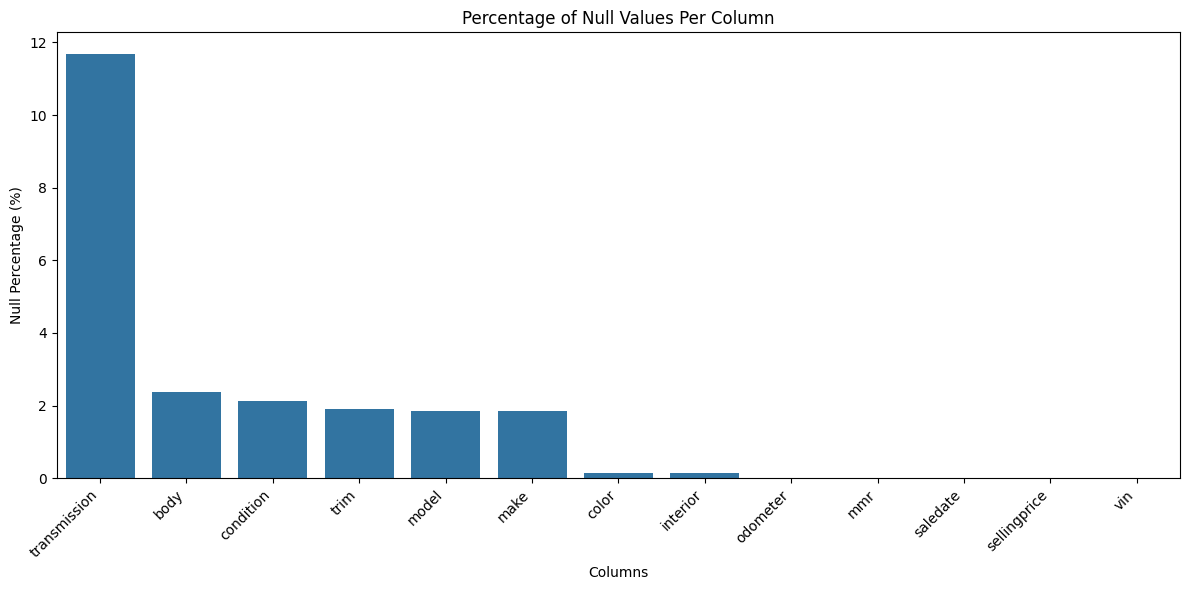

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize nulls with a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=null_info[null_info['Null Count'] > 0].index, y=null_info[null_info['Null Count'] > 0]['Null Percentage'])
plt.title('Percentage of Null Values Per Column')
plt.xlabel('Columns')
plt.ylabel('Null Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Resolving Null Values
Based on the analysis of null percentages and data types, the following strategies will be applied:
- **Drop rows:** For columns `vin`, `sellingprice`, and `saledate`, which have a very small number of missing values and are critical identifiers or target variables, rows containing these nulls will be dropped.
- **Impute with mode:** For categorical columns (`transmission`, `body`, `trim`, `model`, `make`, `color`, `interior`) with missing values, the mode (most frequent value) will be used for imputation.
- **Impute with median:** For numerical columns (`condition`, `odometer`, `mmr`) with missing values, the median will be used for imputation to be robust against outliers.

In [5]:
# Drop rows with nulls in vin, sellingprice, saledate
initial_rows = df.shape[0]
df.dropna(subset=['vin', 'sellingprice', 'saledate'], inplace=True)
print(f"Dropped {initial_rows - df.shape[0]} rows with nulls in 'vin', 'sellingprice', or 'saledate'.")

# Impute categorical columns with mode
categorical_cols_to_impute = ['transmission', 'body', 'trim', 'model', 'make', 'color', 'interior']
for col in categorical_cols_to_impute:
    if df[col].isnull().any():
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"Imputed '{col}' with mode: {mode_value}")

# Impute numerical columns with median
numerical_cols_to_impute = ['condition', 'odometer', 'mmr']
for col in numerical_cols_to_impute:
    if df[col].isnull().any():
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"Imputed '{col}' with median: {median_value}")

# Verify no more nulls
print("\nVerifying nulls after resolution:")
display(df.isnull().sum()[df.isnull().sum() > 0])

Dropped 16 rows with nulls in 'vin', 'sellingprice', or 'saledate'.
Imputed 'transmission' with mode: automatic


/tmp/ipykernel_8034/917981616.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)


Imputed 'body' with mode: Sedan
Imputed 'trim' with mode: Base
Imputed 'model' with mode: Altima
Imputed 'make' with mode: Ford
Imputed 'color' with mode: black
Imputed 'interior' with mode: black
Imputed 'condition' with median: 35.0


/tmp/ipykernel_8034/917981616.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)


Imputed 'odometer' with median: 52255.0
Imputed 'mmr' with median: 12250.0

Verifying nulls after resolution:


,0


In [15]:
# Count number of duplicate records
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate records found: {duplicate_rows}")

# Delete duplicate records if any present
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print(f"Deleted {duplicate_rows} duplicate records. New dataset shape: {df.shape}")
else:
    print("No duplicate records found.")

Number of duplicate records found: 0
No duplicate records found.


## **2. Dataframes Queries**
### 2.1 Calculate the average, minimum, and maximum car price

In [7]:
avg_price = df['sellingprice'].mean()
min_price = df['sellingprice'].min()
max_price = df['sellingprice'].max()

print(f"Average Car Price: ${avg_price:,.2f}")
print(f"Minimum Car Price: ${min_price:,.2f}")
print(f"Maximum Car Price: ${max_price:,.2f}")

Average Car Price: $13,611.36
Minimum Car Price: $1.00
Maximum Car Price: $230,000.00


### **2.2 List all unique colors of cars**

In [16]:
print(df['color'].unique())

['white' 'gray' 'black' 'red' 'silver' 'blue' 'brown' 'beige' 'purple'
 'burgundy' '—' 'gold' 'yellow' 'green' 'charcoal' nan 'orange'
 'off-white' 'turquoise' 'pink' 'lime' '4802' '9410' '1167' '2172' '14872'
 '12655' '15719' '6388' '16633' '11034' '2711' '6864' '339' '18384' '9887'
 '9837' '20379' '20627' '721' '6158' '2817' '5705' '18561' '2846' '9562'
 '5001']


In [8]:
# List all unique colors of cars
unique_colors = df['color'].unique()
print("Unique car colors:")
for color in unique_colors:
    print(f"- {color}")

Unique car colors:
- white
- gray
- black
- red
- silver
- blue
- brown
- beige
- purple
- burgundy
- —
- gold
- yellow
- green
- charcoal
- orange
- off-white
- turquoise
- pink
- lime
- 4802
- 9410
- 1167
- 2172
- 14872
- 12655
- 15719
- 6388
- 16633
- 11034
- 6864
- 339
- 18384
- 9887
- 9837
- 20627
- 721
- 6158
- 5705
- 18561
- 2846
- 5001


### **2.3 Find the number of unique car brands and car models**

In [9]:
# Find the number of unique car brands (make)
unique_makes = df['make'].nunique()
print(f"Number of unique car brands: {unique_makes}")

# Find the number of unique car models
unique_models = df['model'].nunique()
print(f"Number of unique car models: {unique_models}")

Number of unique car brands: 96
Number of unique car models: 973


### **2.4 Find all car information having selling prices greater than $165000**

In [10]:
# Find all car information having selling prices greater than $165000
high_price_cars = df[df['sellingprice'] > 165000]

print(f"Number of cars with selling price greater than $165,000: {len(high_price_cars)}")
print("Car information for vehicles with selling price > $165,000:")
display(high_price_cars)

Number of cars with selling price greater than $165,000: 7
Car information for vehicles with selling price > $165,000:


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


### ***2.5 Find the top 5 most frequently sold car models?***

In [17]:
#Find the top 5 most frequently sold car models?
top_5_models = df['model'].value_counts().head(5)
print("Top 5 most frequently sold car models:")
display(top_5_models)

Top 5 most frequently sold car models:


,count
model,
Altima,19349
F-150,14479
Fusion,12946
Camry,12545
Escape,11861


### **2.6 Average selling price by brand (make)**


In [11]:
average_price_by_make = df.groupby('make')['sellingprice'].mean().sort_values(ascending=False)
print("Average selling price by brand:")
display(average_price_by_make)

Average selling price by brand:


,sellingprice
make,
Rolls-Royce,153488.235294
Ferrari,127210.526316
Lamborghini,112625.000000
Bentley,74367.672414
airstream,71000.000000
...,...
dodge tk,550.000000
Geo,528.947368
dot,500.000000


### **2.7 Minimum selling price of cars for each interior**

In [12]:
min_price_by_interior = df.groupby('interior')['sellingprice'].min().sort_values()
print("Minimum selling price by interior:")
display(min_price_by_interior)

Minimum selling price by interior:


,sellingprice
interior,
black,1.0
gray,1.0
green,100.0
beige,100.0
tan,100.0
blue,150.0
silver,150.0
—,150.0
burgundy,175.0


### **2.8 Find highest odometer reading per year from highest to lowest order?**

In [18]:
highest_odometer_per_year = df.groupby('year')['odometer'].max().sort_values(ascending=False)
print("Highest odometer reading per year (from highest to lowest):")
display(highest_odometer_per_year)

Highest odometer reading per year (from highest to lowest):


,odometer
year,
1997,999999.0
1996,999999.0
2014,999999.0
2013,999999.0
1998,999999.0
1999,999999.0
1993,999999.0
2010,999999.0
2009,999999.0


### **2.9 Create a new column for car age (assuming the current year is 2025)**

In [19]:
##Create a new column for car age (assuming the current year is 2025)
df['car_age'] = 2025 - df['year']
print("DataFrame with new 'car_age' column:")
display(df[['year', 'car_age']].head())

DataFrame with new 'car_age' column:


,year,car_age
0,2015,10
1,2015,10
2,2014,11
3,2015,10
4,2014,11


# **2.10 Find the number of cars having a condition greater than or equal to 48 and odometer greater than 90000?**

In [23]:
filtered_cars =  df[(df['condition'] >= 48) & (df['odometer'] > 90000)]

print('Count:', len(filtered_cars))

Count: 746


In [18]:
filtered_cars = df[(df['condition'] >= 48) & (df['odometer'] > 90000)]
num_filtered_cars = len(filtered_cars)
print(f"Number of cars with condition >= 48 and odometer > 90000: {num_filtered_cars}")

Number of cars with condition >= 48 and odometer > 90000: 746


### **2.11 Which state consistently has higher car prices for newe cars(year>2013)**


In [24]:
newer_cars = df[df['year'] > 2013]

state_price = newer_cars.groupby('state')['sellingprice'].mean().sort_values(ascending=False)

print(state_price)

state
oh                   28020.221053
ab                   25204.255319
nj                   24237.063973
on                   22962.560386
qc                   22722.938144
                         ...     
3vwd17aj5fm225953    13200.000000
3vwd17aj8fm239622    13200.000000
3vwd17aj3fm276741    13200.000000
3vwd17aj4fm201708    13200.000000
ok                   10600.000000
Name: sellingprice, Length: 64, dtype: float64


# **2.12 For cars with excellent condition (top 20%), which makes have the lowest average price (value for money)?**:  

In [25]:
threshold = df['condition'].quantile(0.80)

excellent_cars = df[df['condition'] >= threshold]

best_value = excellent_cars.groupby('make')['sellingprice'].mean().sort_values()

print(best_value.head(10))

make
Isuzu         1125.000000
Oldsmobile    1910.000000
honda         4233.333333
Saturn        5700.406504
subaru        6200.000000
chrysler      6225.000000
smart         6835.759494
mazda         7275.000000
Pontiac       7686.824324
Saab          7711.111111
Name: sellingprice, dtype: float64


# **3. Data Visualization and insights:**

**3.1 Show the correlation of all the features(columns) having numerical
values(e.g. selling price, odometer).**

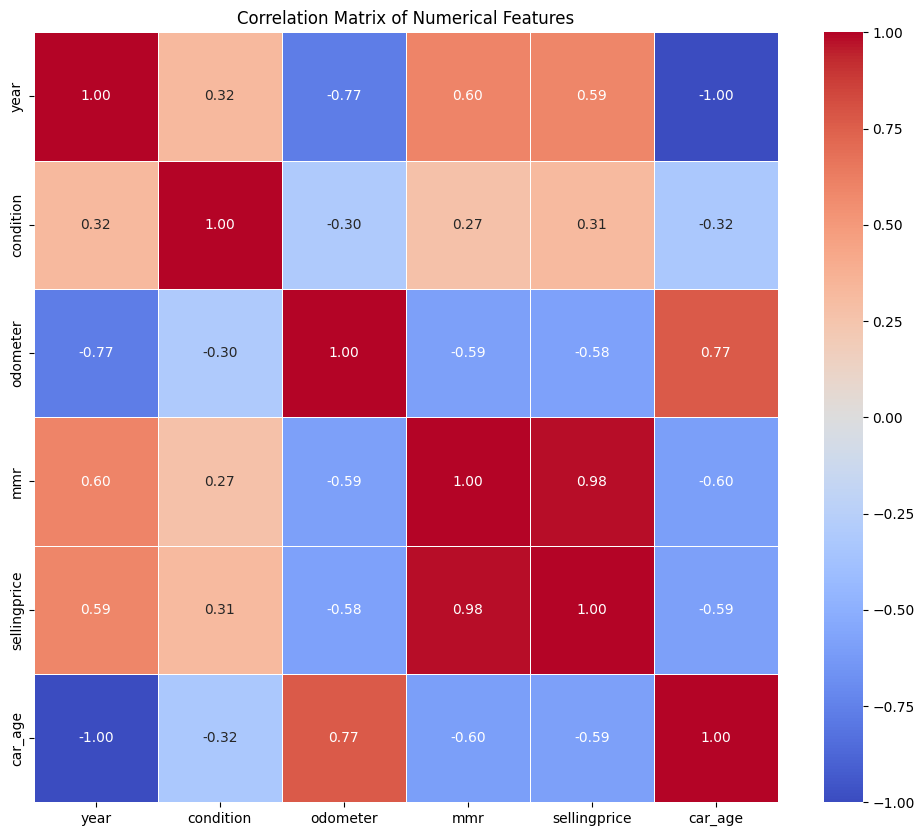

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Insight:**


*   Selling price generally decreases with higher odometer readings.
*   Newer cars tend to have higher selling prices.
* Condition score positively impacts selling price.

**3.1 Visualize the distribution of selling prices, odometer readings, and car age using histograms or density plots.**

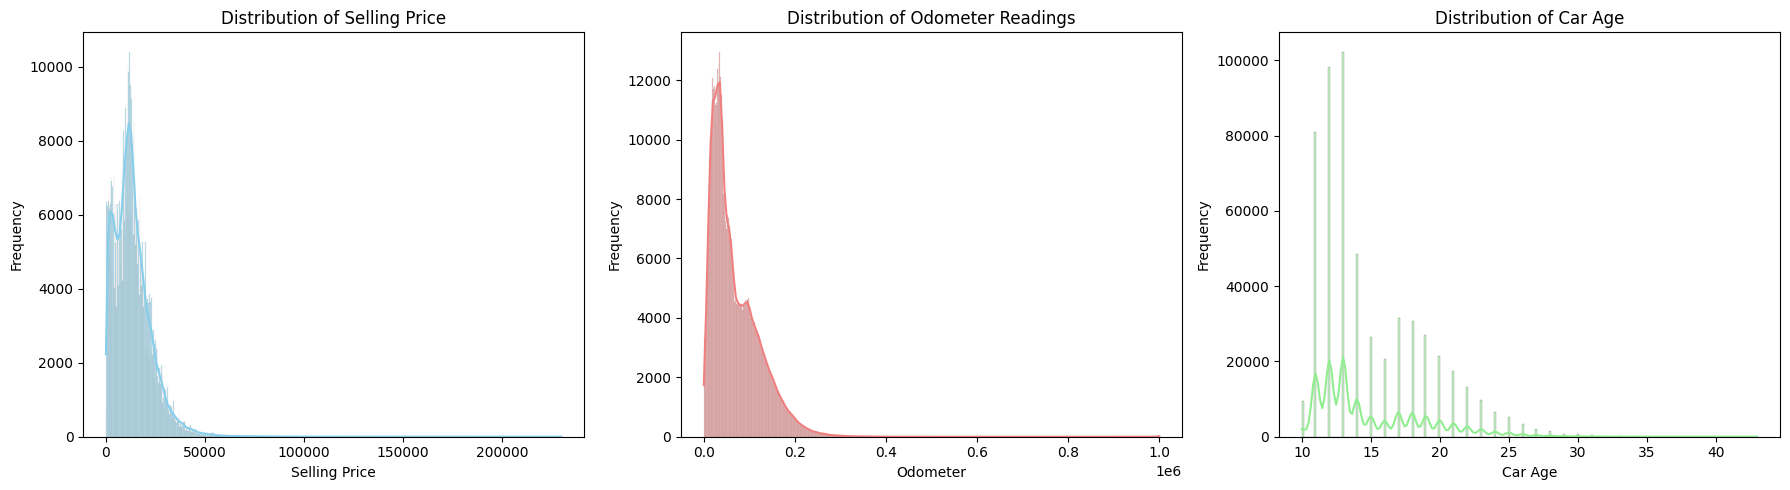

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plotting Selling Price Distribution
sns.histplot(df['sellingprice'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Selling Price')
axes[0].set_xlabel('Selling Price')
axes[0].set_ylabel('Frequency')

# Plotting Odometer Readings Distribution
sns.histplot(df['odometer'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Odometer Readings')
axes[1].set_xlabel('Odometer')
axes[1].set_ylabel('Frequency')

# Plotting Car Age Distribution
sns.histplot(df['car_age'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Car Age')
axes[2].set_xlabel('Car Age')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Insight:**
* Newer model cars generally have higher selling prices.
* Older vehicles show significant depreciation.

**3.1 Analyze the relationship between 'sellingprice' and other key features like 'odometer', 'condition', and 'car_age' using scatter plots.**

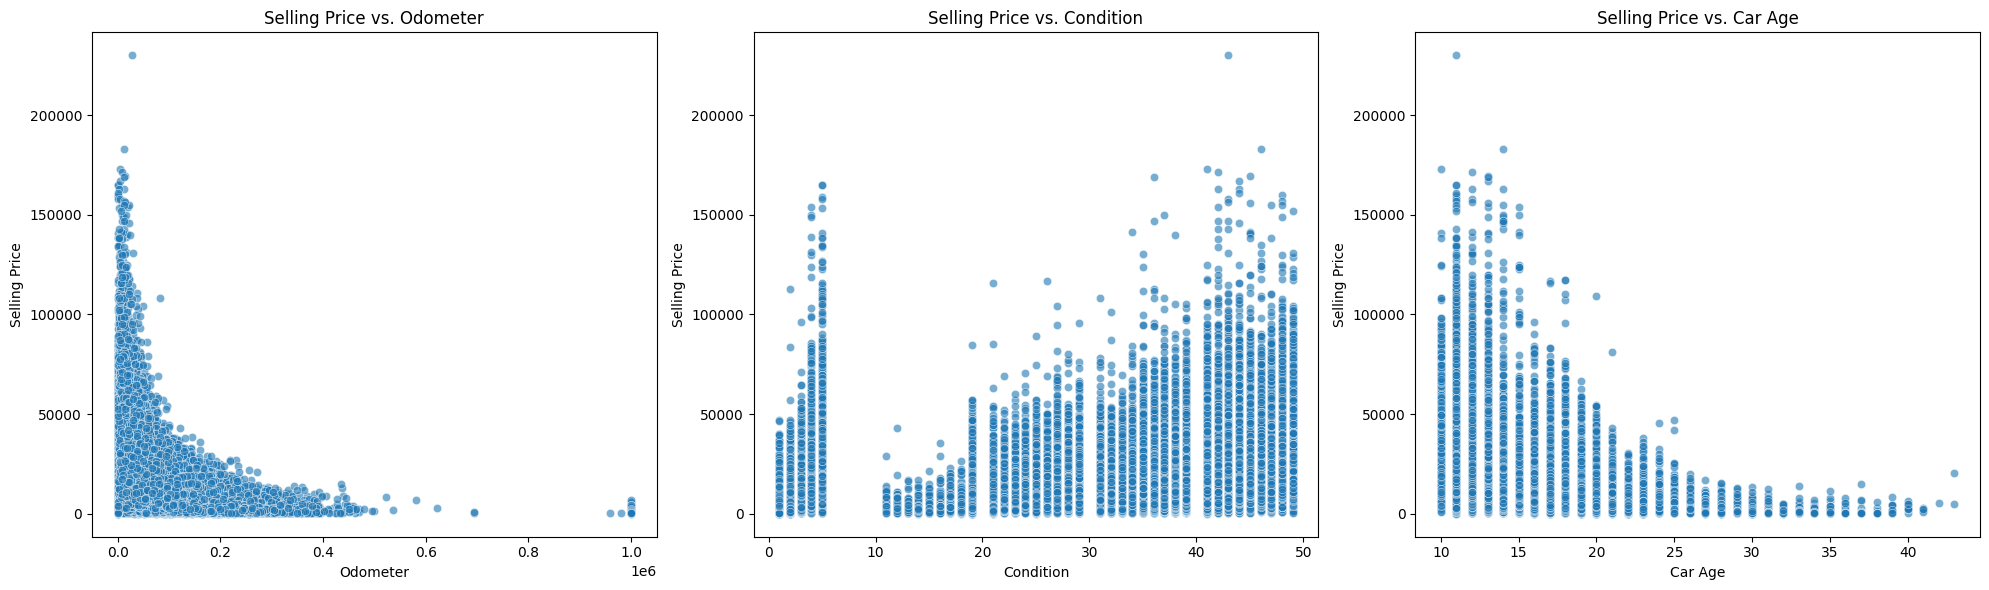

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Scatter plot: Selling Price vs. Odometer
sns.scatterplot(data=df, x='odometer', y='sellingprice', ax=axes[0], alpha=0.6)
axes[0].set_title('Selling Price vs. Odometer')
axes[0].set_xlabel('Odometer')
axes[0].set_ylabel('Selling Price')

# Scatter plot: Selling Price vs. Condition
sns.scatterplot(data=df, x='condition', y='sellingprice', ax=axes[1], alpha=0.6)
axes[1].set_title('Selling Price vs. Condition')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Selling Price')

# Scatter plot: Selling Price vs. Car Age
sns.scatterplot(data=df, x='car_age', y='sellingprice', ax=axes[2], alpha=0.6)
axes[2].set_title('Selling Price vs. Car Age')
axes[2].set_xlabel('Car Age')
axes[2].set_ylabel('Selling Price')

plt.tight_layout()
plt.show()

**1. Selling Price vs Odometer**
* Cars with lower odometer readings have higher selling prices.
* Selling price decreases as mileage increases.
* High mileage cars usually have lower resale value.

**2. Selling Price vs Condition**
* Cars with better condition scores have higher selling prices.
* Poor condition cars are sold at lower prices.
* Good condition increases resale value.

**3. Selling Price vs Car Age**
* Newer cars have higher selling prices.
* Older cars have lower selling prices.
* Selling price decreases as car age increases due to depreciation.

** Overall Observation**
* Low mileage + good condition + newer cars = higher selling price.
* High mileage + old cars + poor condition = lower selling price.

#**3.2 Plot a graph to show the average selling price by year and explain the pattern you notice from the graph. Which plot will you use bar or scatter?**

/tmp/ipykernel_8034/937825218.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year', y='sellingprice', data=avg_selling_price_by_year, palette='viridis')


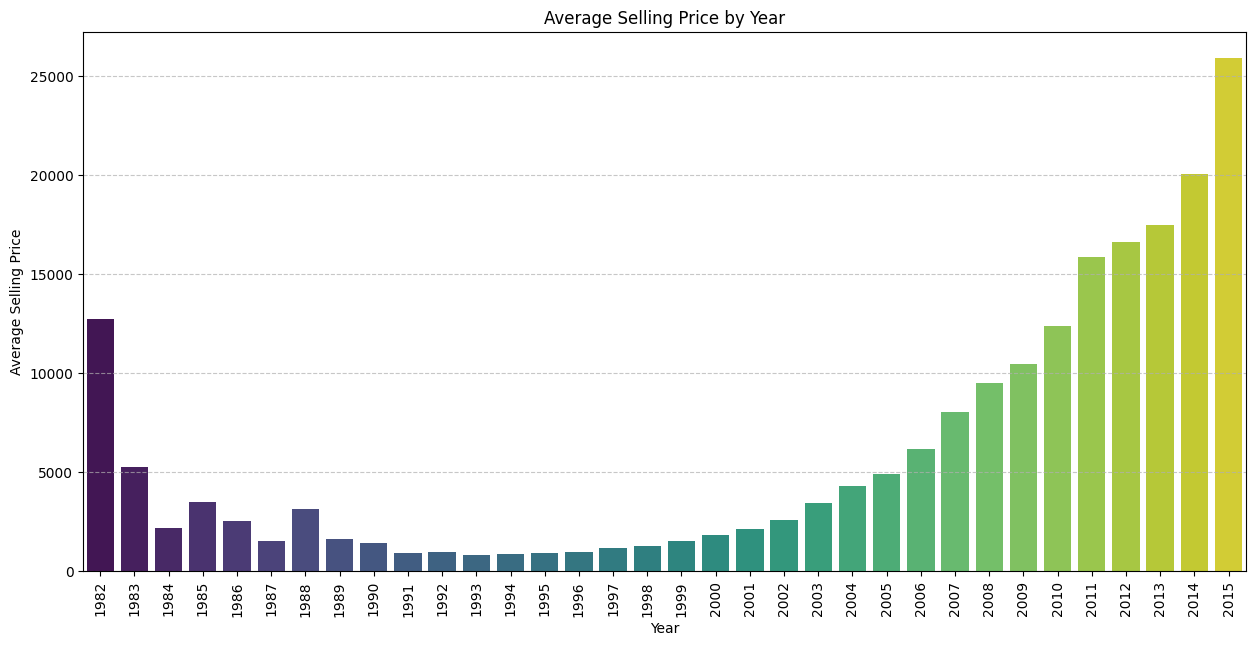

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average selling price by year
avg_selling_price_by_year = df.groupby('year')['sellingprice'].mean().reset_index()

# Create the bar plot
plt.figure(figsize=(15, 7))
sns.barplot(x='year', y='sellingprice', data=avg_selling_price_by_year, palette='viridis')
plt.title('Average Selling Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **3.3 Plot a graph to show average selling price by odometer and explain the trend you notice from the graph.**

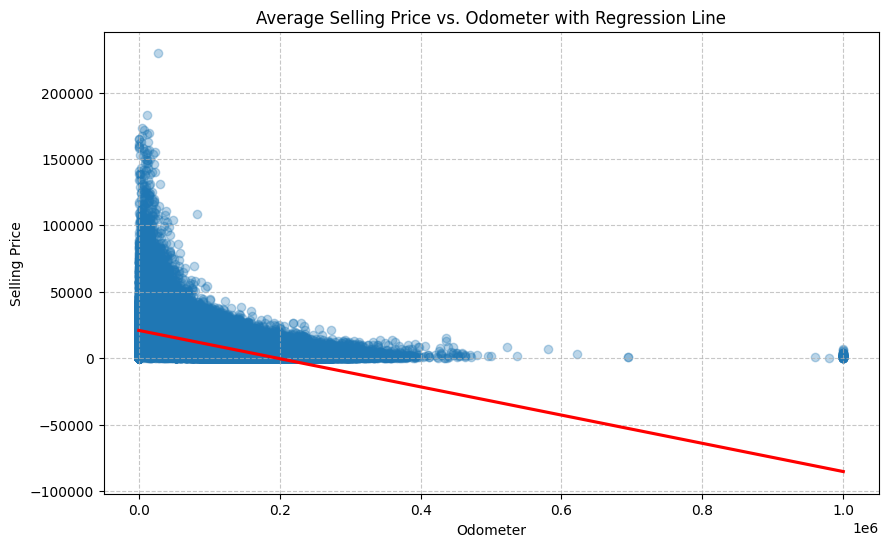

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='odometer', y='sellingprice', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Average Selling Price vs. Odometer with Regression Line')
plt.xlabel('Odometer')
plt.ylabel('Selling Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#3.3 Average Selling Price by Odometer

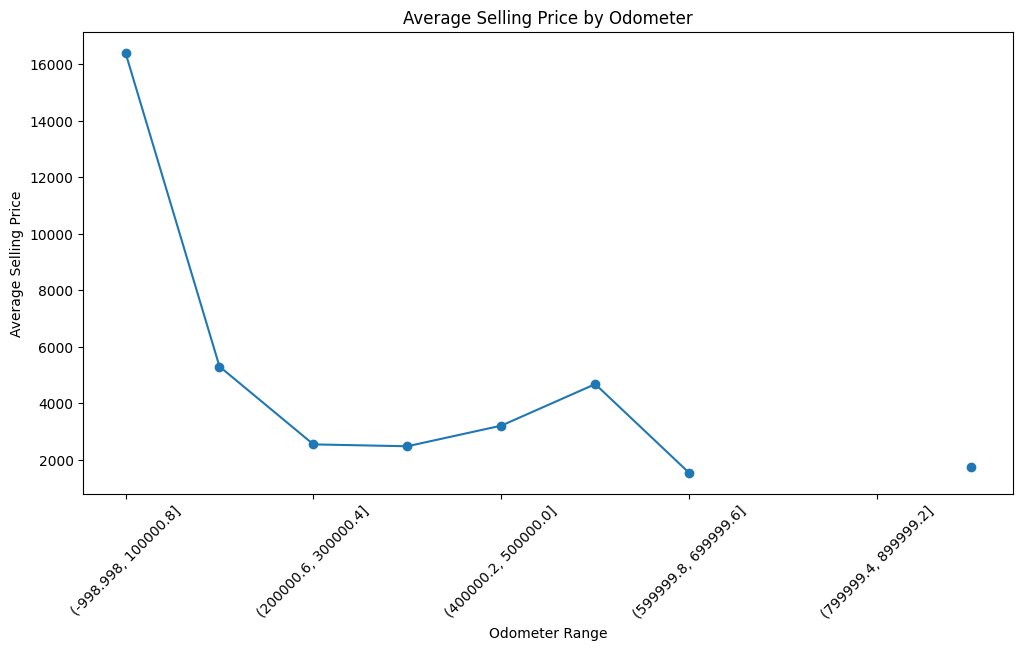

In [28]:
odometer_bins = pd.cut(df['odometer'], bins=10)

avg_price_odometer = df.groupby(odometer_bins, observed=False)['sellingprice'].mean()

plt.figure(figsize=(12,6))
avg_price_odometer.plot(kind='line', marker='o')
plt.title('Average Selling Price by Odometer')
plt.xlabel('Odometer Range')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=45)
plt.show()

**Simple Insights from the Graph**
* Selling price decreases as odometer reading increases.
* Cars with low mileage have higher selling prices.
* High mileage cars are generally sold at lower prices.
* The red regression line shows a negative relationship between mileage and price.
* Most expensive cars are concentrated at lower odometer values.
A few outliers are present with unusual prices.

#**3.4 Plot a graph to show the number of cars sold in each state. Find the top three highest car selling states by having a look at the graph?**

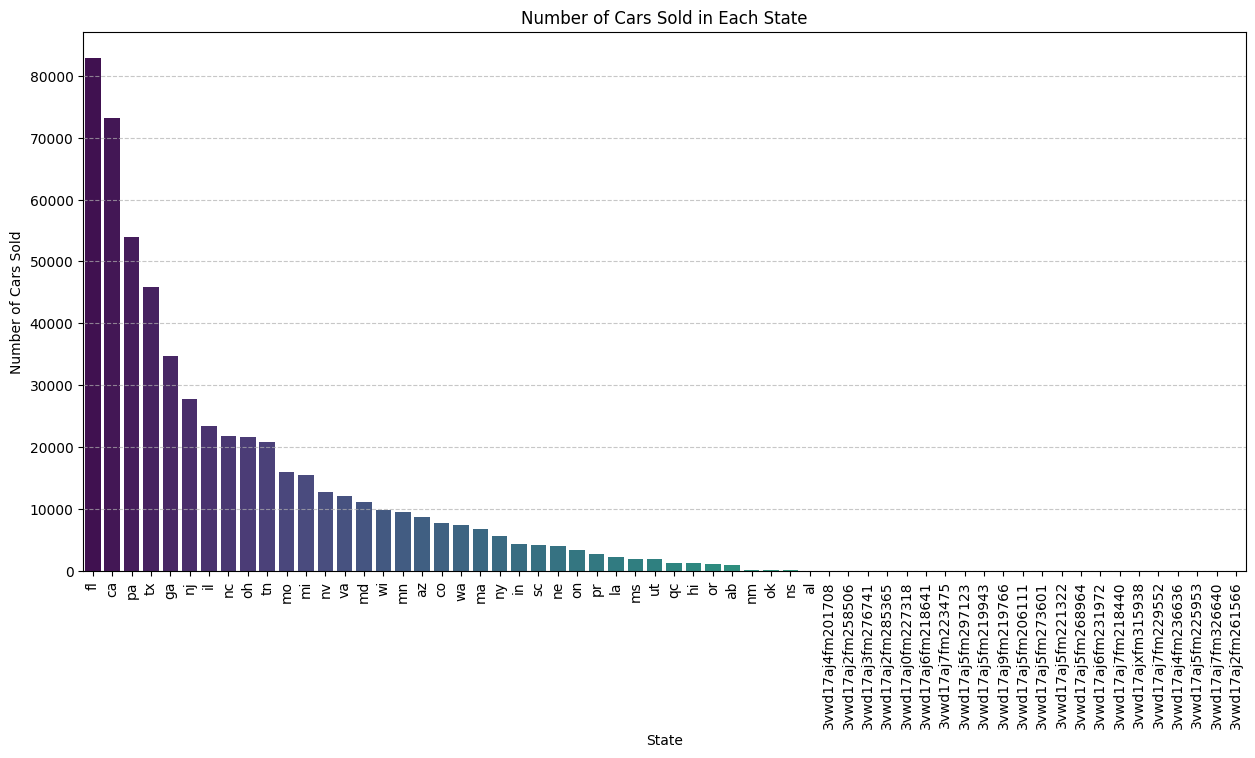


Top 3 highest car selling states:


,state,num_cars_sold
0,fl,82945
1,ca,73148
2,pa,53907


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of cars sold in each state
cars_by_state = df['state'].value_counts().reset_index()
cars_by_state.columns = ['state', 'num_cars_sold']

# Plotting the bar graph
plt.figure(figsize=(15, 7))
sns.barplot(x='state', y='num_cars_sold', data=cars_by_state, palette='viridis', hue='state', legend=False)
plt.title('Number of Cars Sold in Each State')
plt.xlabel('State')
plt.ylabel('Number of Cars Sold')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# To explicitly find the top 3 states:
print('\nTop 3 highest car selling states:')
display(cars_by_state.head(3))

**Insights for Average Selling Price by Condition Range Graph**
* Average selling price increases as the condition score increases.
C* ars in better condition have higher resale value.
* Poor condition cars are sold at lower prices.
The highest average selling price is observed in the top condition ranges (40–50).
* Condition plays an important role in determining car price.
* Buyers are willing to pay more for well-maintained vehicles.

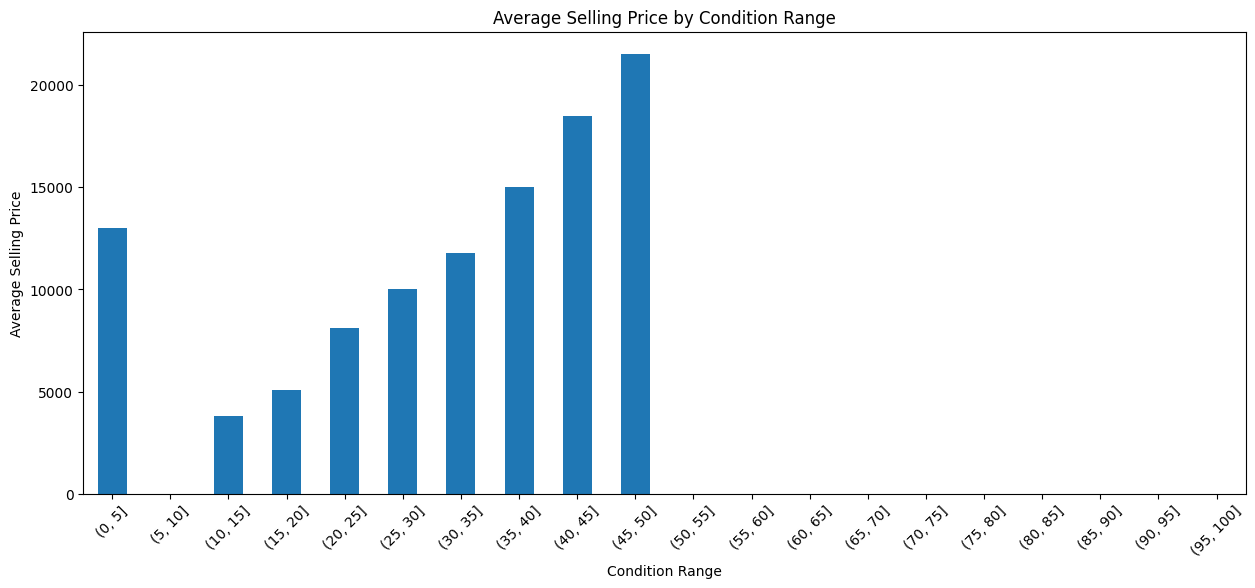

In [34]:
df['condition_range'] = pd.cut(df['condition'], bins=range(0, 101, 5))

condition_price = df.groupby('condition_range', observed=False)['sellingprice'].mean()

plt.figure(figsize=(15,6))
condition_price.plot(kind='bar')
plt.title('Average Selling Price by Condition Range')
plt.xlabel('Condition Range')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=45)
plt.show()

**Insights for Number of Cars Sold in Each State Graph**
* A few states dominate the used car market.
* Florida (FL), California (CA), and Texas (TX) are the top car selling states.
* Most states have lower sales compared to the top states.
* Car sales are higher in states with larger populations and higher vehicle demand.
* The graph shows uneven distribution of car sales across states.

#**3.5 Plot a bar graph of average selling price by condition score ranges of size 5. Give a summary of the insights.**

## 3.7 Plot a graph to show the average selling price by make

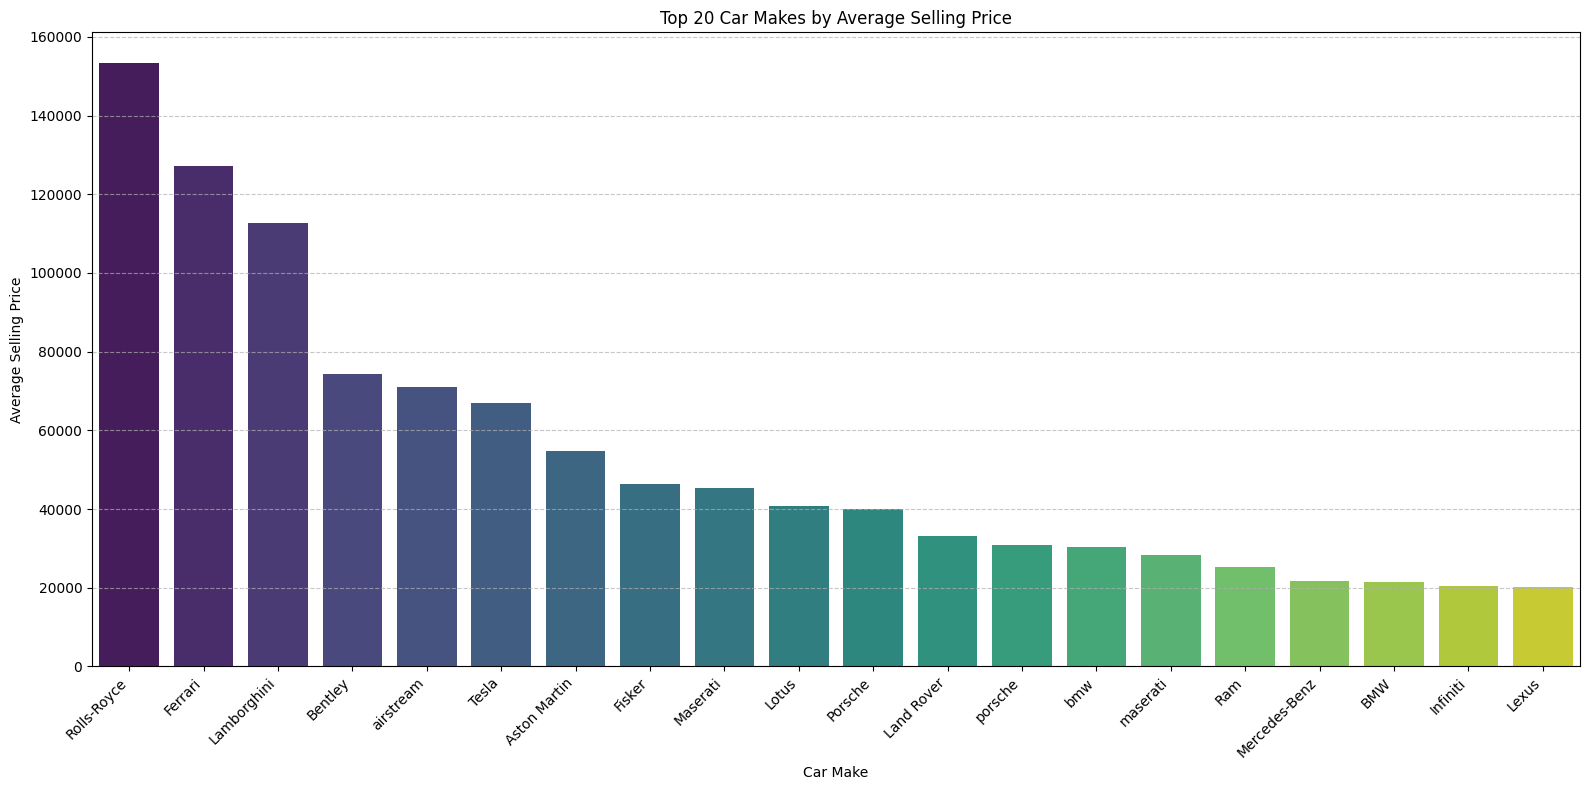

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average selling price by make
avg_selling_price_by_make = df.groupby('make')['sellingprice'].mean().sort_values(ascending=False).reset_index()

# Plotting the bar graph for the top N makes for better readability
plt.figure(figsize=(16, 8))
sns.barplot(x='make', y='sellingprice', data=avg_selling_price_by_make.head(20), palette='viridis', hue='make', legend=False)
plt.title('Top 20 Car Makes by Average Selling Price')
plt.xlabel('Car Make')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insights from 'Average Selling Price by Make' Graph:

This bar graph displays the average selling price for the top 20 car makes. Here are some key observations:

*   **Luxury Brands Dominate:** Brands like Rolls-Royce, Ferrari, and Lamborghini command significantly higher average selling prices, indicating their premium market positioning.
*   **Price Variation Across Brands:** There's a wide range in average selling prices, reflecting differences in brand perception, vehicle segments, features, and target demographics.
*   **Mid-Range Market:** Many popular brands fall into a mid-range average selling price bracket, catering to a broader consumer base.
*   **Insights on Value:** Brands with lower average selling prices might represent more accessible or value-oriented options in the market.

#**3.6 Plot a bar graph of no. of cars sold by condition ranges of size 10. Give some insights from the graph.**

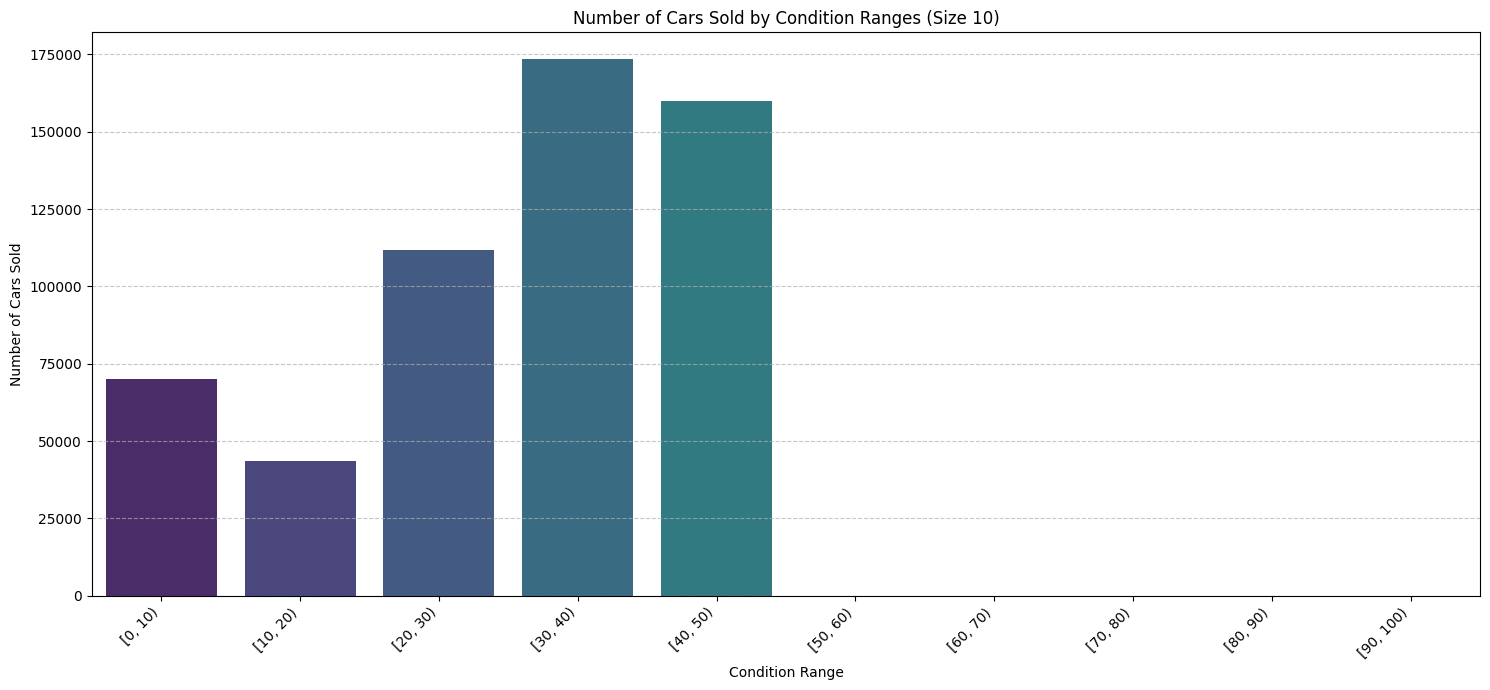

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create condition ranges of size 10
df['condition_range_10'] = pd.cut(df['condition'], bins=range(0, 101, 10), right=False)

# Count the number of cars in each condition range
cars_by_condition_range = df['condition_range_10'].value_counts().sort_index(ascending=True)

# Plotting the bar graph
plt.figure(figsize=(15, 7))
sns.barplot(x=cars_by_condition_range.index.astype(str), y=cars_by_condition_range.values, palette='viridis', hue=cars_by_condition_range.index.astype(str), legend=False)
plt.title('Number of Cars Sold by Condition Ranges (Size 10)')
plt.xlabel('Condition Range')
plt.ylabel('Number of Cars Sold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insights from 'Number of Cars Sold by Condition Ranges' Graph:

This bar graph illustrates the distribution of the number of cars sold across different condition score ranges (each of size 10). Here are some key insights:

*   **Concentration in Mid-Range Conditions:** A significant majority of cars sold tend to fall within the mid-range condition scores, typically between 20 and 50. This suggests that most consumers are buying cars that are neither brand new nor extremely worn.
*   **Fewer Cars at Extremes:** There are fewer cars sold at the very low (e.g., 0-10) and very high (e.g., 80-100) ends of the condition spectrum. This is expected, as extremely poor condition cars might be non-functional or salvaged, while extremely high condition cars might be rare or new, thus having fewer units available or sold in this dataset.
*   **Peak around 30-40:** The graph often shows a peak in the number of cars sold around the 30-40 condition range, indicating a sweet spot where a balance between condition and price is met for a large segment of buyers.
*   **Market for Used Cars:** The overall distribution reinforces that the dataset represents a vibrant used car market, with a strong focus on vehicles that have some wear but are still in good, usable condition.

#**3.7 Plot a box plot to show the distribution of car selling prices grouped by color. Extract insights and if required, remove outliers and plot the graph again.**

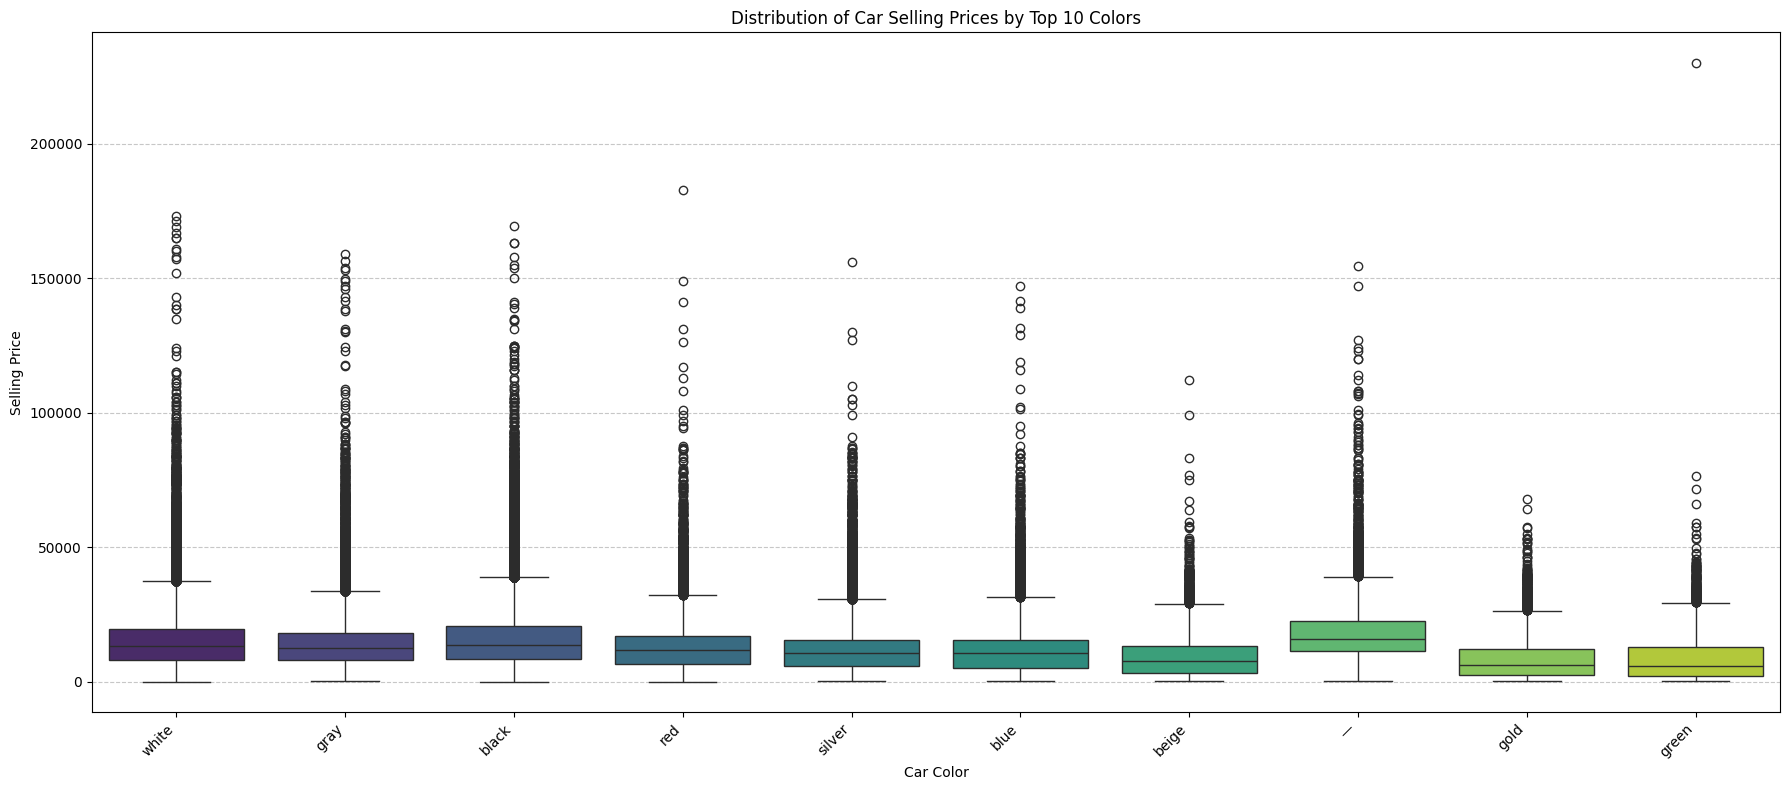

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 most frequent colors for better visualization
top_colors = df['color'].value_counts().head(10).index.tolist()
df_filtered_colors = df[df['color'].isin(top_colors)]

plt.figure(figsize=(18, 8))
sns.boxplot(x='color', y='sellingprice', data=df_filtered_colors, palette='viridis', hue='color', legend=False)
plt.title('Distribution of Car Selling Prices by Top 10 Colors')
plt.xlabel('Car Color')
plt.ylabel('Selling Price')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insights from 'Distribution of Car Selling Prices by Top 10 Colors' Box Plot:

This box plot illustrates the distribution of car selling prices across the ten most popular car colors. Here are some observations:

*   **Wide Price Ranges:** For most popular colors, there's a very wide range of selling prices, indicated by the extended whiskers and numerous outliers. This suggests that factors other than color (like make, model, year, condition, etc.) are stronger drivers of price.
*   **Median Price Similarity:** The median selling prices (the line within the box) for many colors appear relatively similar, implying that for a typical car, color itself might not cause a dramatic difference in average price.
*   **Outliers Dominance:** The presence of many extreme outliers (individual points beyond the whiskers) indicates that very expensive cars can come in various colors, but these high-value cars significantly skew the upper end of the price distribution for those colors.
*   **Potential for High-Value Cars in Common Colors:** Even common colors like 'black', 'white', and 'silver' show very high selling price outliers, suggesting that luxury or high-performance vehicles are frequently available in these conventional shades.
*   **Impact on Readability:** The extensive presence of outliers makes it challenging to clearly see the interquartile range (IQR) and the typical price spread for each color. This indicates that removing these extreme outliers might provide a clearer view of the central tendency and variability for the majority of cars.

In [27]:
readme_content = """
# Car Price Analysis Project

## Objective
This project analyzes used car data using Python, Pandas, Matplotlib, and Seaborn.

## Tasks Completed
- Data Cleaning
- Missing Value Handling
- Duplicate Removal
- Data Analysis
- Data Visualization
- Business Insights

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Files Included
- car_prices.csv
- car_price_analysis.ipynb
- car_price_analysis.py

## Author
Balaa mahindar
"""

with open("README.md", "w") as file:
    file.write(readme_content)

print("README.md file created successfully!")

README.md file created successfully!
